In [174]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.patches import FancyArrowPatch
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 10
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})

C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:23: RuntimeWarning: divide by zero encountered in divide
  r_trj = p / (1 - np.cos(theta1))
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:24: RuntimeWarning: invalid value encountered in multiply
  trj = rot(90) @ (r_trj * np.array([np.cos(theta1), np.sin(theta1)]))
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:46: RuntimeWarning: divide by zero encountered in divide
  r_par = p_par / (1 - e_par*np.cos(theta2))
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:47: RuntimeWarning: invalid value encountered in matmul
  par = rot(90) @ (r_par * np.array([np.cos(theta2), np.sin(theta2)]))
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:53: RuntimeWarning: divide by zero encountered in divide
  r_hyp = p_hyp / (1 - e_hyp*np.cos(theta_hyp))
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\3899216428.py:54: RuntimeWarning: invalid value encountered in matmul
  hyp

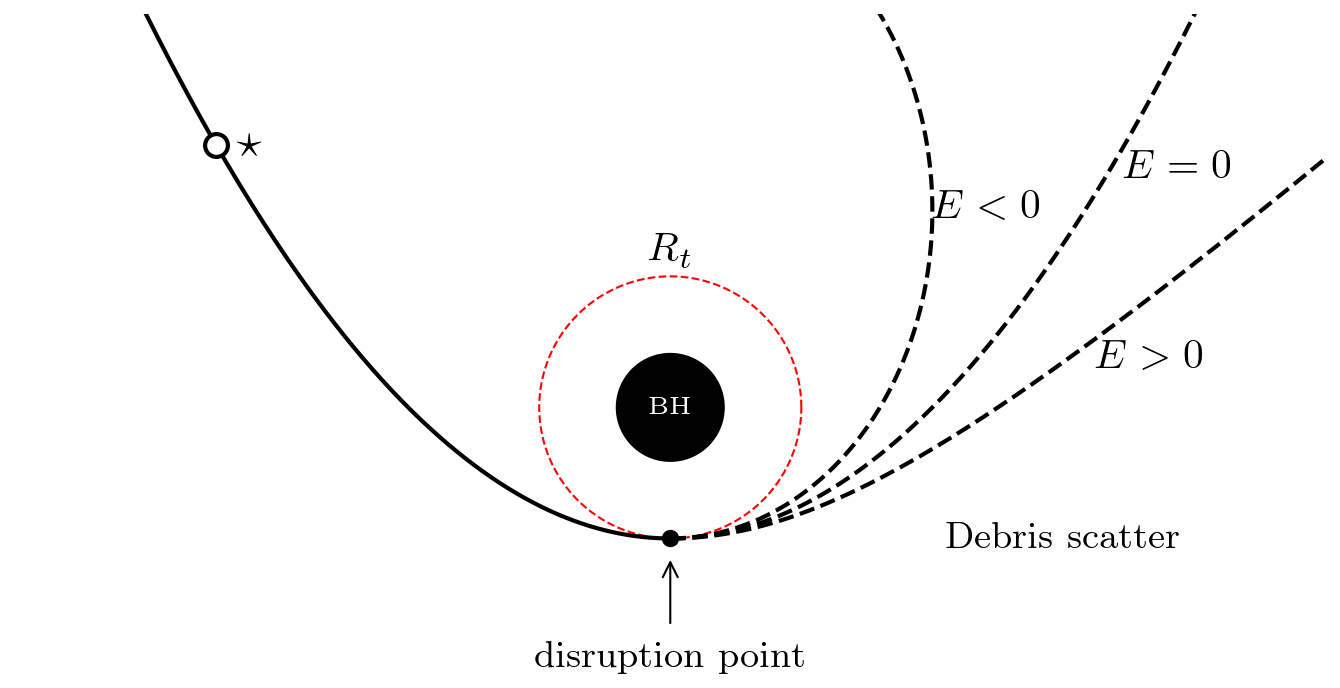

In [175]:
plt.figure(figsize = (5,2.5), dpi = 300)
plt.gca().set_aspect('equal')

bh = np.array([0,0])

theta  = np.linspace(0, 2*np.pi, 720)
theta1 = np.linspace(0, np.pi, 360)
theta2 = np.linspace(np.pi, 2*np.pi, 360)

rbh = 0.4
bhr = rbh * np.array([np.cos(theta), np.sin(theta)])

rt = np.array([np.cos(theta), np.sin(theta)])

def rot(theta):
    theta *= np.pi / 180
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

p = 2
r_trj = p / (1 - np.cos(theta1))
trj = rot(90) @ (r_trj * np.array([np.cos(theta1), np.sin(theta1)]))

# Star: on the solid parabola, just before periapsis
thetastar = np.deg2rad(60)
r_star = p / (1 - np.cos(thetastar))
p_star = rot(90) @ (r_star * np.array([np.cos(thetastar), np.sin(thetastar)]))

plt.scatter(*p_star, c='w', edgecolor = 'k', s=30, zorder = 3)

plt.scatter(*[0,-1], c='k', s=10, zorder = 3)

rp = p / 2

# Ellipse
e_ell = 0.6
p_ell = rp * (1 + e_ell)
r_ell = p_ell / (1 - e_ell*np.cos(theta2))
ell = rot(90) @ (r_ell * np.array([np.cos(theta2), np.sin(theta2)]))

# Parabola following theta2
e_par = 1.0
p_par = rp * (1 + e_par)
r_par = p_par / (1 - e_par*np.cos(theta2))
par = rot(90) @ (r_par * np.array([np.cos(theta2), np.sin(theta2)]))

# Hyperbola
e_hyp = 1.5
p_hyp = rp * (1 + e_hyp)
theta_hyp = np.linspace(-np.pi, -np.arccos(1/e_hyp), 360)
r_hyp = p_hyp / (1 - e_hyp*np.cos(theta_hyp))
hyp = rot(90) @ (r_hyp * np.array([np.cos(theta_hyp), np.sin(theta_hyp)]))

plt.plot(*rt, 'r--', lw = 0.5)
plt.plot(*trj, 'k-', lw = 1)
plt.plot(*ell, 'k--', lw = 1)
plt.plot(*hyp, 'k--', lw = 1)
plt.plot(*par, 'k--', lw = 1)

plt.fill(*bhr, color = 'k')

# --- annotations ---
plt.annotate(r'$\star$', p_star + np.array([0.25, 0]), ha='center', va='center', fontsize=12)

# label points on each curve (pick off-axis theta2 samples)
i_ell = np.argmin(np.abs(theta2 - np.deg2rad(310)))
plt.annotate(r'$E<0$', ell[:, i_ell], ha='left', va='top', fontsize=10)

i_par = np.argmin(np.abs(theta2 - np.deg2rad(300)))
plt.annotate(r'$E=0$', par[:, i_par], ha='left', va='top', fontsize=10)

i_hyp = len(theta_hyp)//4 * 3
plt.annotate(r'$E>0$', hyp[:, i_hyp], ha='left', va='top', fontsize=10)

# Rt on tidal radius (periapsis, at distance rp from BH)
plt.annotate(r'$R_t$', (0, + rp + 0.2), ha='center', va='center', fontsize=10)

# disruption point at periapsis
plt.annotate('disruption point', (0, -rp - 0.1), xytext=(0, -rp-0.9),
             ha='center', va='center', fontsize=9,
             arrowprops=dict(arrowstyle='->', lw=0.5))

plt.annotate('BH', (0, 0), ha='center', va='center', color='w', fontsize=6, zorder=4)

plt.annotate('Debris scatter',(3,-1) ,ha='center', va='center', fontsize = 9)
plt.xlim(-5,5)
plt.ylim(-2,3)
plt.tight_layout()
plt.axis('off')
plt.tight_layout()
plt.savefig('approach.pdf')
plt.show()

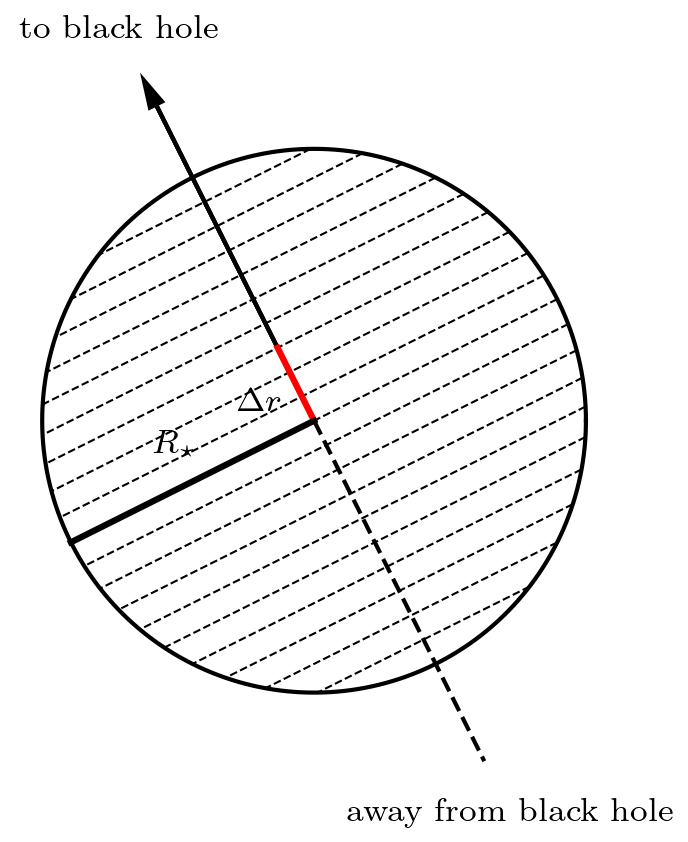

In [176]:
theta = np.linspace(0, 2*np.pi, 720)

r = np.array([np.cos(theta), np.sin(theta)])

axis = np.array([-1, 2], dtype=float)
axis /= np.linalg.norm(axis)
axis *= 1.4

dr = 0.1

# unit vector perpendicular to axis
perp = np.array([-axis[1], axis[0]])
perp /= np.linalg.norm(perp)

plt.figure(figsize = (3,3), dpi = 300)
plt.gca().set_aspect('equal')

plt.plot(*r, 'k-', lw=1)
plt.plot([0, -axis[0]], [0, -axis[1]], 'k--', lw=1)

plt.arrow(0, 0, axis[0], axis[1],
          head_width=0.05, head_length=0.1,
          length_includes_head=True, lw=1, color='k')

A = np.linalg.norm(axis)

# equator chord through the origin (t = 0)
plt.plot([-perp[0], perp[0]], [-perp[1], perp[1]],
         ls='--', lw=0.5, c='k')

# perpendicular chords on both sides of the axis
for sign in (+1, -1):
    t = dr
    while t <= A:
        pt = sign * axis * (t / A)
        h = np.sqrt(max(0.0, 1.0 - pt.dot(pt)))
        plt.plot(
            [pt[0] - h*perp[0], pt[0] + h*perp[0]],
            [pt[1] - h*perp[1], pt[1] + h*perp[1]],
            ls='--', lw=0.5, c='k'
        )
        t += dr

# --- annotations ---

# arrow tip = "to black hole", tail = "away from black hole"
plt.annotate('to black hole', axis, xytext=axis + 0.15*axis,
             ha='center', va='center', fontsize=8)
plt.annotate('away from black hole', -axis, xytext=-axis - 0.15*axis,
             ha='center', va='center', fontsize=8)

# Delta r: small segment along the axis of length dr
r0 = axis * (0 / A)   # start at 30% along the axis
r1 = r0 + (axis / A) * 3 * dr
plt.plot([r0[0], r1[0]], [r0[1], r1[1]], 'r-', lw=1.5)
plt.annotate(r'$\Delta r$', (r0 + r1)/2 + 0.15*perp,
             ha='center', va='center', fontsize=8)

# R_star: segment along the equator from origin to the circle edge
Rs = perp  # radius 1 along perp
plt.plot([0, Rs[0]], [0, Rs[1]], 'k-', lw=1.5)
plt.annotate(r'$R_\star$', Rs/2 + 0.15*axis/A,
             ha='center', va='center', fontsize=8)

plt.axis('off')
plt.tight_layout()
plt.savefig('slices.pdf')
plt.show()

In [177]:
def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX- for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=10)

C:\Users\verci\AppData\Local\Temp\ipykernel_13640\770398432.py:17: RuntimeWarning: divide by zero encountered in power
  Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\770398432.py:17: RuntimeWarning: invalid value encountered in subtract
  Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s


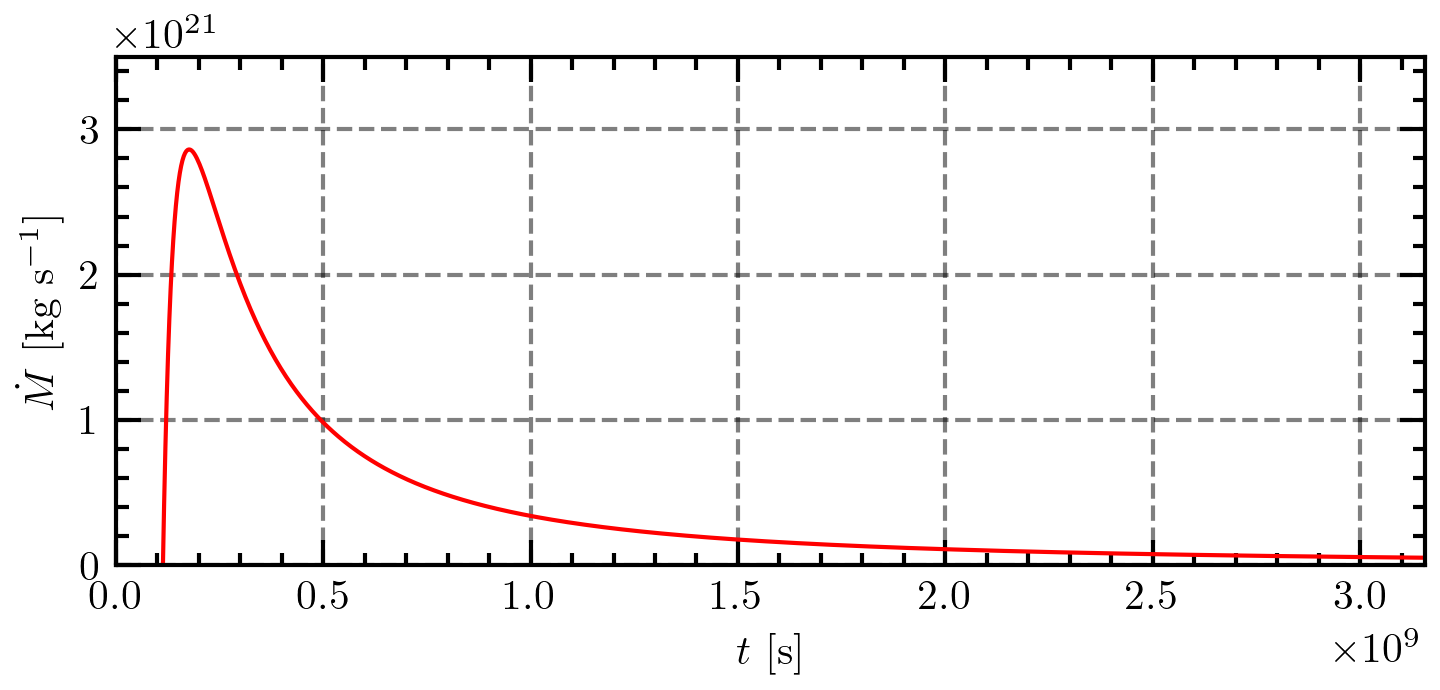

In [178]:
M_sol = 1.989e30       # kg
M_bh  = 10e7 * M_sol   # kg
R_sol = 6.957e8        # m
R_t = R_sol * (4 * M_bh / M_sol)**(1/3)
R_p = R_t
G = 6.67430e-11        # m^3 kg^-1 s^-2

dE = (G * M_bh / R_p**2) * R_sol   # J/kg  (specific energy)

yr = 365.25 * 24 * 60**2           # s

T = np.linspace(0, 100 * yr, 1000)

A_term = (M_sol * (2*np.pi*G*M_bh)**(2/3)) / (3 * dE)
B_term = (M_sol * (2*np.pi*G*M_bh)**(2))    / (16 * dE**3)

Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s

plt.figure(figsize = (5,2.5), dpi = 300)
plt.plot(T, Mdot, 'r-', lw = 1)
plt.ylim(0, 3.5e21)
plt.xlim(0, 100 * yr)
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$\dot{M}$ [kg $\mathrm{s}^{-1}$]')
plt.tight_layout()
plt.savefig("mdot-metric.pdf")
plt.show()

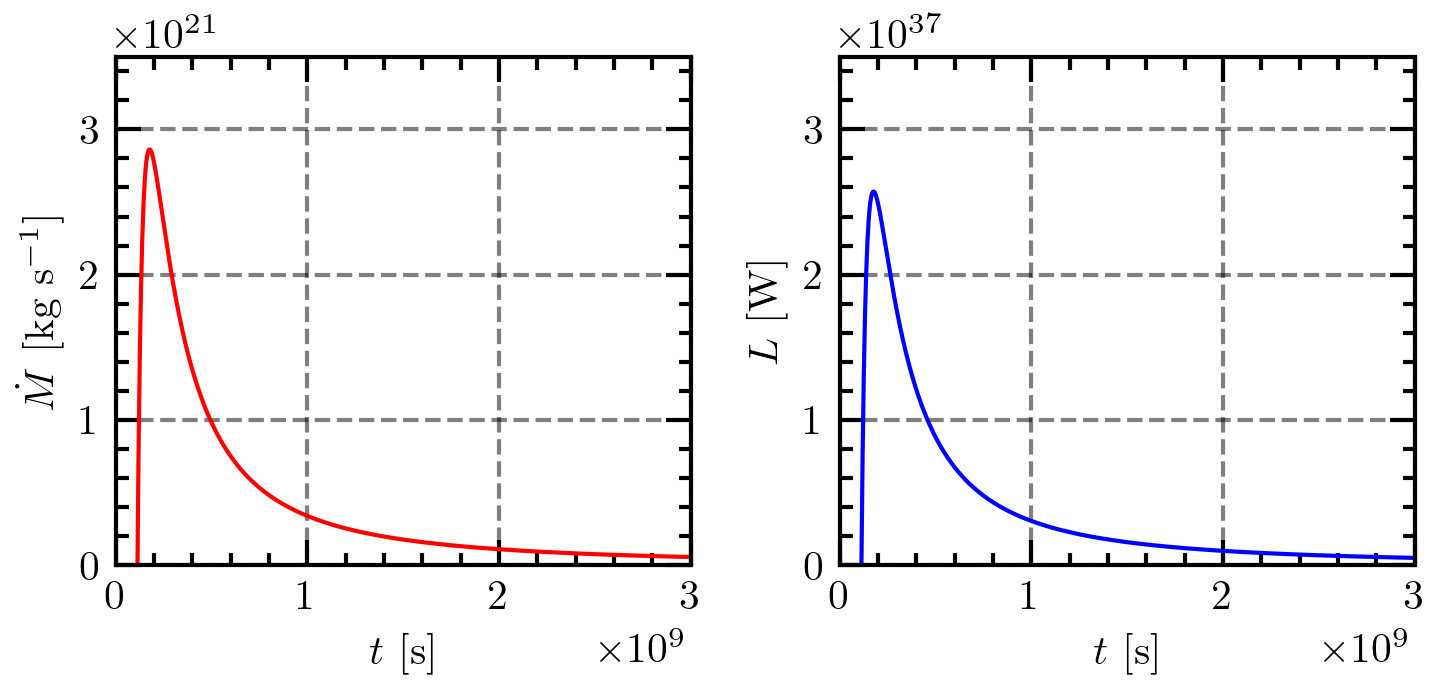

In [188]:
M_sol = 1.989e30       # kg
M_bh  = 10e7 * M_sol   # kg
R_sol = 6.957e8        # m
R_t = R_sol * (4 * M_bh / M_sol)**(1/3)
R_p = R_t
G = 6.67430e-11        # m^3 kg^-1 s^-2

dE = (G * M_bh / R_p**2) * R_sol   # J/kg

yr = 365.25 * 24 * 60**2           # s

T = np.linspace(0.1, 100 * yr, 1000)

A_term = (M_sol * (2*np.pi*G*M_bh)**(2/3)) / (3 * dE)
B_term = (M_sol * (2*np.pi*G*M_bh)**2)    / (16 * dE**3)

Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s

# --- luminosity ---
eta = 0.1
c = 299792458                              # m/s
L = eta * c**2 * Mdot                       # W


fig, ax = plt.subplots(
    1, 2,
    figsize=(5, 2.5),
    dpi=300
)

# --- mass fallback rate ---
ax[0].plot(T, Mdot, 'r-', lw=1)
ax[0].set_xlim(0, 3e9)
ax[0].set_ylim(0, 3.5e21)
ax[0].set_xlabel(r'$t$ [s]')
ax[0].set_ylabel(r'$\dot{M}$ [kg $\mathrm{s}^{-1}$]')

# --- luminosity ---
ax[1].plot(T, L, 'b-', lw=1)
ax[1].set_xlim(0, 3e9)
ax[1].set_ylim(0, 3.5e37)
ax[1].set_xlabel(r'$t$ [s]')
ax[1].set_ylabel(r'$L$ [W]')

plt.tight_layout()
plt.savefig("mdot-lumens-metric.pdf")
plt.show()

C:\Users\verci\AppData\Local\Temp\ipykernel_13640\576399338.py:17: RuntimeWarning: divide by zero encountered in power
  Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s
C:\Users\verci\AppData\Local\Temp\ipykernel_13640\576399338.py:17: RuntimeWarning: invalid value encountered in subtract
  Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s


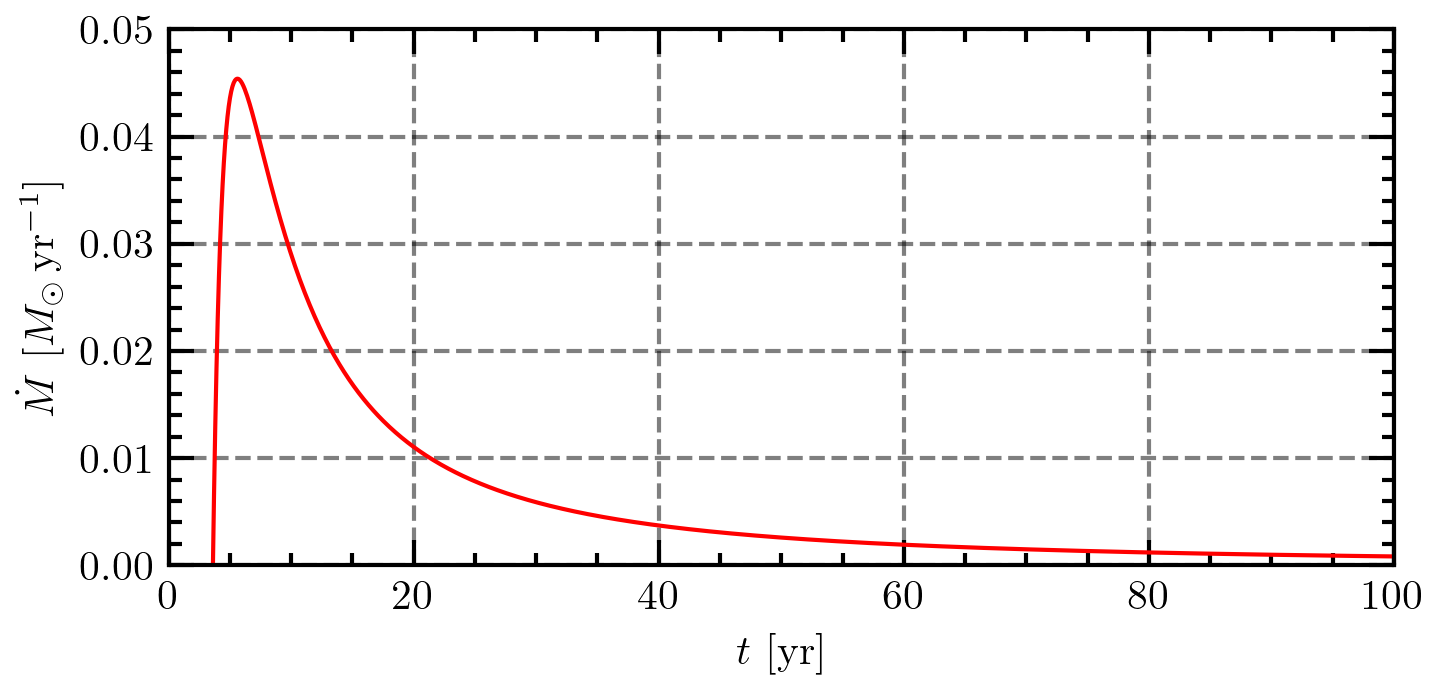

In [180]:
M_sol = 1.989e30       # kg
M_bh  = 10e7 * M_sol   # kg
R_sol = 6.957e8        # m
R_t = R_sol * (4 * M_bh / M_sol)**(1/3)
R_p = R_t
G = 6.67430e-11        # m^3 kg^-1 s^-2

dE = (G * M_bh / R_p**2) * R_sol   # J/kg  (specific energy)

yr = 365.25 * 24 * 60**2           # s

T = np.linspace(0, 100 * yr, 1000)

A_term = (M_sol * (2*np.pi*G*M_bh)**(2/3)) / (3 * dE)
B_term = (M_sol * (2*np.pi*G*M_bh)**(2))    / (16 * dE**3)

Mdot = A_term * T**(-5/3) - B_term * T**(-3)   # kg/s

# --- convert for plotting ---
T_yr   = T    / yr          # s -> yr
Mdot_s = Mdot / M_sol * yr  # kg/s -> M_sol/yr

plt.figure(figsize = (5,2.5), dpi = 300)
plt.plot(T_yr, Mdot_s, 'r-', lw = 1)
plt.ylim(0, 0.05)
plt.xlim(0, 100)
plt.xlabel(r'$t$ [yr]')
plt.ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
plt.tight_layout()
plt.savefig("mdot.pdf")
plt.show()

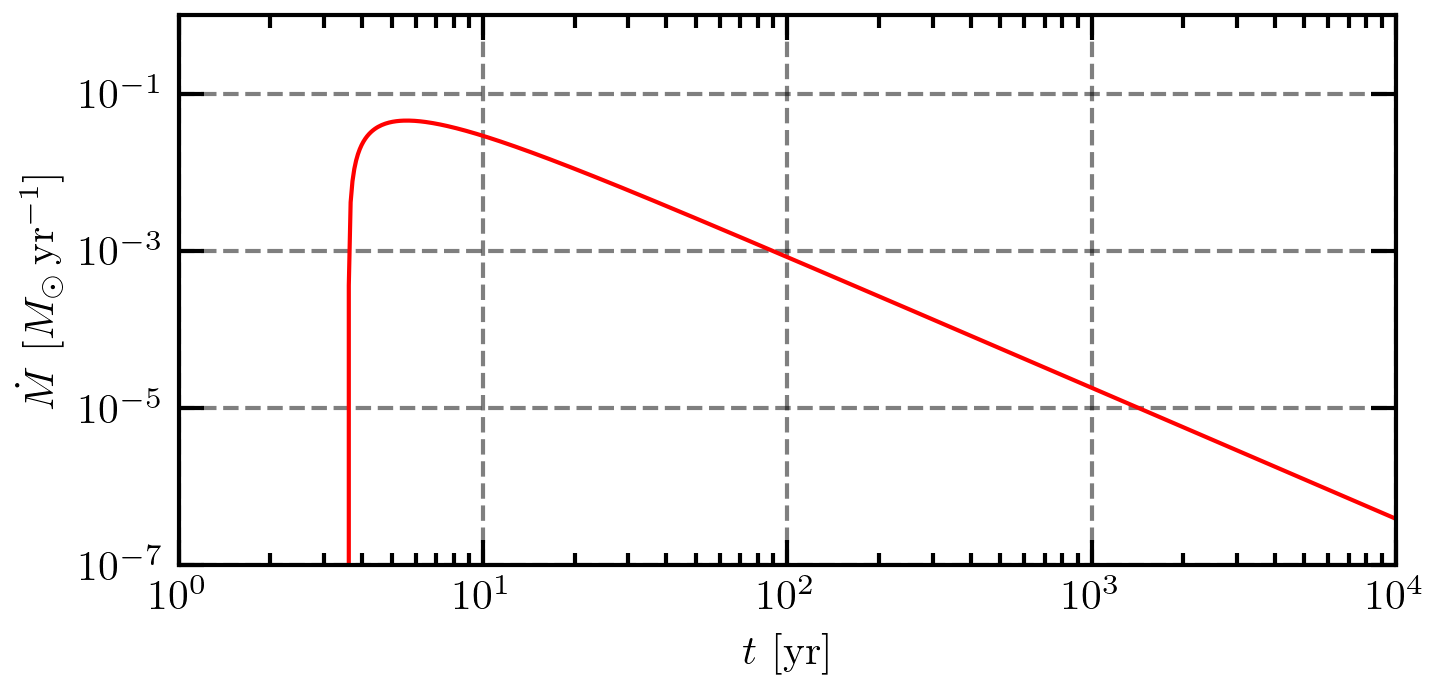

In [181]:
T = np.logspace(-2, 4, 1000) * yr   # 0.01 to 100 yr

A_term = (M_sol * (2*np.pi*G*M_bh)**(2/3)) / (3 * dE)
B_term = (M_sol * (2*np.pi*G*M_bh)**2) / (16 * dE**3)

Mdot = A_term * T**(-5/3) - B_term * T**(-3)

# --- convert for plotting ---
T_yr   = T / yr
Mdot_s = Mdot / M_sol * yr

plt.figure(figsize = (5,2.5), dpi = 300)
plt.loglog(T_yr, Mdot_s, 'r-', lw = 1)

plt.xlabel(r'$t$ [yr]')
plt.ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')

plt.xlim(1e-0, 1e4)
plt.ylim(1e-7, 1e0)
plt.tight_layout()
plt.savefig("mdot-log.pdf")
plt.show()

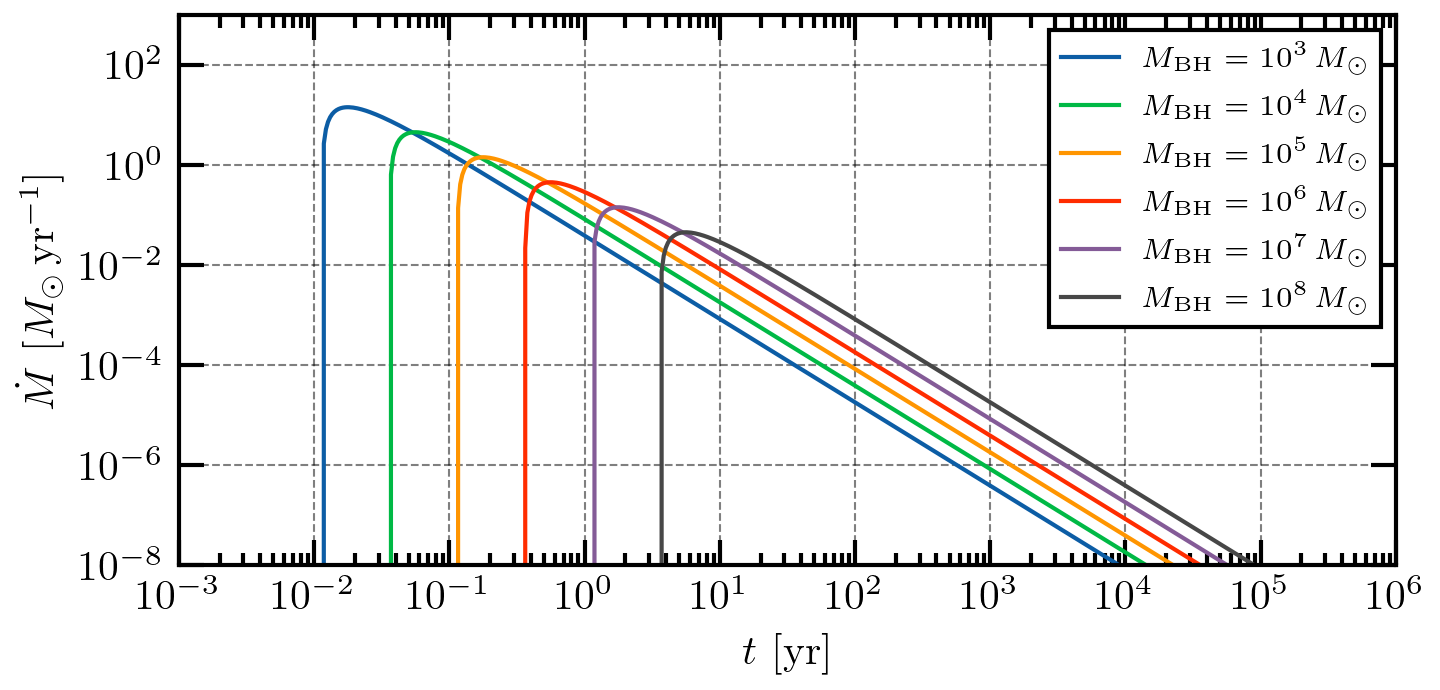

In [182]:
M_sol = 1.989e30       # kg
R_sol = 6.957e8        # m
G = 6.67430e-11        # m^3 kg^-1 s^-2

yr = 365.25 * 24 * 60**2   # s

plt.figure(figsize=(5, 2.5), dpi=300)

for M_bh_solar in np.logspace(3, 8, 6):

    M_bh = M_bh_solar * M_sol

    R_t = R_sol * (4 * M_bh / M_sol)**(1/3)
    R_p = R_t

    dE = (G * M_bh / R_p**2) * R_sol   # J/kg

    T = np.logspace(
        -2,
        np.log10(1e6 * yr),
        1000
    )

    A_term = (M_sol * (2*np.pi*G*M_bh)**(2/3)) / (3 * dE)
    B_term = (M_sol * (2*np.pi*G*M_bh)**2) / (16 * dE**3)

    Mdot = A_term * T**(-5/3) - B_term * T**(-3)

    # --- convert for plotting ---
    T_yr = T / yr
    Mdot_s = Mdot / M_sol * yr

    plt.loglog(
        T_yr,
        Mdot_s,
        lw=1,
        label=fr'$M_{{\rm BH}} = 10^{{{int(np.log10(M_bh_solar))}}}\,M_\odot$'
    )

plt.xlabel(r'$t$ [yr]')
plt.ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
plt.xlim(1e-3, 1e6)
plt.ylim(1e-8, 1e3)
plt.grid(True, alpha = 0.5, lw = 0.5)
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("mdot_mbh.pdf")
plt.show()

In [ ]:
plt.figure(figsize = (4,3), dpi = 300)